# Loading In Necessary Libraries

<style>
    /* Forces the table to stretch to 100% of the screen/container width */
    table {
        width: 100% !important;
    }
    /* Adds spacing inside the cells so the text isn't cramped */
    th, td {
        padding: 10px 15px !important;
    }
</style>

In [1]:
import torch
import neml2
import matplotlib.pyplot as plt
from pyzag import nonlinear, chunktime
import numpy as np
from scipy.optimize import brentq

# Data Handling and Device Management
Ensuring data-type is ```torch.double``` and on ```CUDA``` (Pytorch GPU engine) if available and otherwise on CPU

In [2]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 13.0


# Model Setup
This class is a thin wrapper around the underlying ```pyzag``` wrapper for NEML2 (```pyzag``` is NEML2's nonlinear recursive solver built in python for handling forward/backward integration and solving the adjoint sensitivities). This takes in the input conditions (time, temperature, strain), combines them into a single tensor, calls the ```pyzag``` wrapper, and returns the stress. For this particular model, the class also handles the input for the initial dislocation density $\rho_m$. This is done by adding an attribute to ```self``` as ```self.initial_rho_m = initial_rho_m```.

To improve Newton-Raphson solver stability, the length scale units are in $\mu \mathrm{m}$ instead of $\mathrm{m}$. The model inputs for the length scales and constants are as follows:

| Length Scale Parameters | Value |
| :----------------------- | :-----: |
| Lattice constant $a \quad [\mu\mathrm{m}]$ | $3.16\times10^{-4}$ |
| Burger's Vector $b \quad [\mu\mathrm{m}]$ | $2.737\times10^{-4}$ |
| Kink Height $H \quad [\mu\mathrm{m}]$ | $2.581\times10^{-4}$ |
| Initial dislocation density $\rho_m \quad [\mu\mathrm{m}^2]$ | $10$ |

In [3]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
        initial_rho_m (float): initial mobile dislocation density (m^-2)
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4, initial_rho_m=10.0e12):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )
        
        control = torch.zeros_like(loading)
        control[...,1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading
            }
        ).torch()

        # Initialize state with non-zero rho_m to seed plastic flow.
        # assemble_by_variable fills unspecified variables with zeros automatically.
        state0 = self.discrete_equations.state_asm.assemble_by_variable(
            {
                "state/internal/rho_m": torch.full(
                    forces.shape[1:-1] + (1,), self.initial_rho_m, device=forces.device
                )
            }
        ).torch()

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        
        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        # Return physical stress component explicitly instead of raw first state entry.
        state_hist_raw = self.discrete_equations.state_asm.split_by_variable(neml2.Tensor(result, 2))
        state_hist = {str(k): v.torch() for k, v in state_hist_raw.items()}

        if "state/mixed_state" in state_hist:
            return state_hist["state/mixed_state"][..., 0:1]

        raise KeyError(
            f"Neither state/S nor state/mixed_state found. Available state vars: {sorted(state_hist.keys())}"
        )

# Loading Model from Input file and Applying Pyzag Wrapper
This block loads the implicit rate formulation for the input file ```model_validation.i``` which is read and printed to show the model structure showing the inputs, outputs, parameters, and buffers. The loaded model is then wrapped in both ```Pyzag``` and the thin ```SolveStrain``` class wrapper. The input parameter values are handled entirely in the input file and are set to:

| Parameters | Value |
| :---------- | :-----: |
| Kinematic Hardening Modulus $C \quad [\mathrm{MPa}]$ | 0 |
| Kinematic Dynamic Recovery Coefficient $\gamma_d$ | 0 |
| Storage coefficient $k_1 \quad [\mathrm{m}^-1]$ | 0 |
| Dynamic Recovery coefficient $k_2$ | 0 |
| Sigmoid Sharpness factor $s$ | 0 |
| Peierl's stress $\tau_p \quad [\mathrm{MPa}]$ | 2030 |
| Activation Energy $\Delta H_0 \quad [\mathrm{eV}]$ | 1.63 |
| $\alpha$ | 0 |
| Mobility fitting exponent $p$ | 0 |
| Mobility fitting exponent $q$ | 0 |
| Drag coefficient $B_k \quad [\mathrm{MPa}\cdot\mathrm{s}]$ | $8.3\times10^{-11}$ |
| Athermal Transition Temperature $T_0 \quad [K]$ | 2956 |
| Schmid Factor $m$ | 0.333 |
| Young's Modulus $E \quad [\mathrm{MPa}]$ | 410000 |
| Poisson's Ratio $\nu$ | 0.28 |

In [4]:
nmodel = neml2.load_model("model_validation.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["E_a", "E_b", "E_c", "G_A", "G_bottom_A", "athermal_alpha", "athermal_b",
                                                                            "nu_a", "nu_b", "nu_c", "flow_rate_b", "shear_eff_m", "yield_sy", "v_disl_p",
                                                                            "v_disl_q", "v_disl_tau_p", "v_disl_H_0"]))

Name:       implicit_rate
Input:      forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/X [SR2]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/X [SR2]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/X [SR2]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: athermal_alpha [Scalar][Double][cuda:0]
            athermal_b [Scalar][Double][cuda:0]
            athermal_shear_modulus [Scalar][Double][cuda:0]
            elasticity_E [Scalar][Double][cuda:0]
            elasticity_nu [Scalar][Double][cuda:0]
            flow_rate_b [Scalar][Double][cuda:0]
            kinharden_C [Scalar][Double][cuda:0]
           

# Creating Input Tensors for SolveStrain Class
Testing model at 3 different strain rates: $$\dot{\epsilon}=[6.4\times10^{-2}, 6.4\times10^{-3}, 6.4\times10{-4}] \quad [1/\mathrm{s}]$$

And 6 different temperatures: $$\mathrm{T}=[77, 200, 300, 500, 700, 1000] \quad [\mathrm{K}]$$

The maximum strain is set to `10%` and the model was tested for a total of 18 conditions or independent time series ($n_{\mathrm{batch}}$)

In [5]:
nrate = 3
ntemp = 6
nbatch = nrate * ntemp
max_strain = 0.1
ntime = 200

temperatures = torch.tensor([77, 200, 300, 500, 700, 1000], device=device, dtype=torch.double)
rates = torch.tensor([6.4e-2, 6.4e-3, 6.4e-4], device=device, dtype=torch.double)
conditions = torch.cartesian_prod(temperatures, rates)

time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, (T, rate) in enumerate(conditions):
    loading[:, i, 0] = torch.linspace(0, max_strain, ntime, device=device)
    time[:, i, 0] = torch.linspace(0, max_strain/rate, ntime, device=device)
    temperature[:, i, 0] = T

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")



--- Full Input Tensors ---
time: torch.Size([200, 18, 1])
temperature: torch.Size([200, 18, 1])
loading: torch.Size([200, 18, 6])


# Running Model to Obtain Flow stresses

In [6]:
with torch.no_grad():
    stress = model(time, temperature, loading)
print(stress)
print(stress.shape)


tensor([[[0.0000e+00],
         [0.0000e+00],
         [0.0000e+00],
         ...,
         [0.0000e+00],
         [0.0000e+00],
         [0.0000e+00]],

        [[2.0603e+02],
         [2.0603e+02],
         [2.0603e+02],
         ...,
         [1.6669e-05],
         [1.6669e-06],
         [1.6669e-07]],

        [[4.1206e+02],
         [4.1206e+02],
         [4.1206e+02],
         ...,
         [1.6669e-05],
         [1.6669e-06],
         [1.6669e-07]],

        ...,

        [[3.2252e+03],
         [3.0993e+03],
         [2.9778e+03],
         ...,
         [1.6669e-05],
         [1.6669e-06],
         [1.6669e-07]],

        [[3.2252e+03],
         [3.0993e+03],
         [2.9778e+03],
         ...,
         [1.6669e-05],
         [1.6669e-06],
         [1.6669e-07]],

        [[3.2252e+03],
         [3.0993e+03],
         [2.9778e+03],
         ...,
         [1.6669e-05],
         [1.6669e-06],
         [1.6669e-07]]], device='cuda:0')
torch.Size([200, 18, 1])


# Plotting Results for All Batches

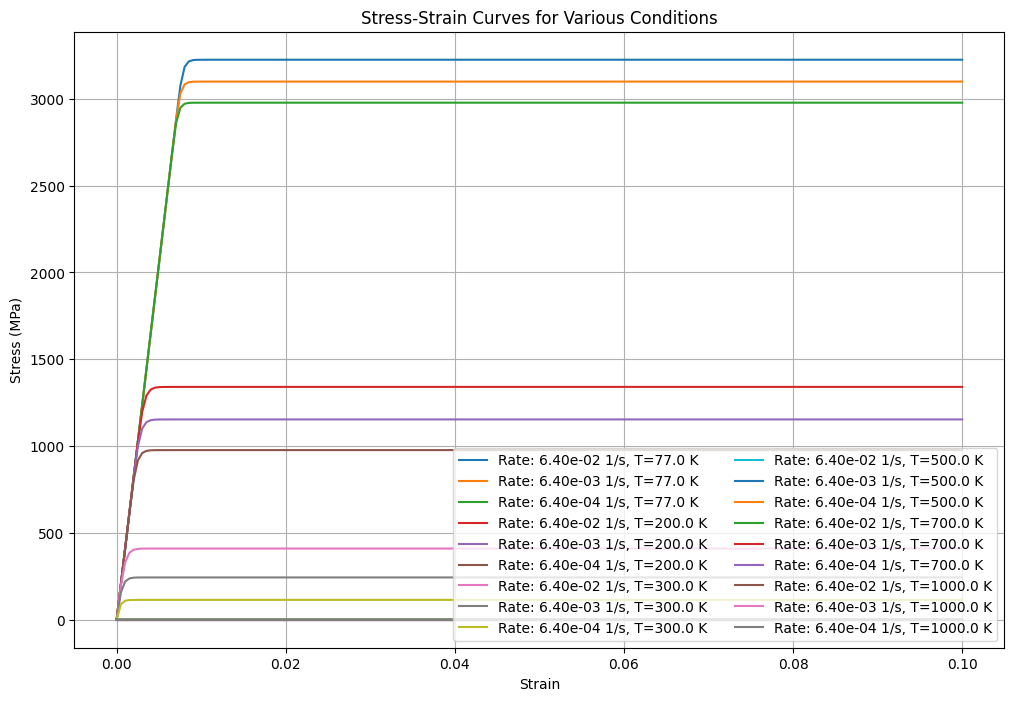

In [7]:
plt.figure(figsize=(12, 8))
for i, (T, rate) in enumerate(conditions):
    plt.plot(loading[:, i, 0].cpu().numpy(), stress[:, i, 0].cpu().numpy(), label=f"Rate: {rate:.2e} 1/s, T={T} K")
plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.title("Stress-Strain Curves for Various Conditions")
plt.legend(loc="lower right", ncol=2)
plt.grid(True)
plt.show()


# Performing Sanity Check to Ensure No Plasticity Accumulation or Dislocation Density Evolution

Available state variables:
  state/internal/X
  state/internal/rho_m
  state/mixed_state
Available force variables:
  forces/T
  forces/control
  forces/fixed_values
  forces/t

Batch    T_f (expected)    T_f in forces/T    Match           E          nu           G     sigma_a
    0             77.00              77.00        ✓   410000.00       0.280   160156.25        0.00
    1             77.00              77.00        ✓   410000.00       0.280   160156.25        0.00
    2             77.00              77.00        ✓   410000.00       0.280   160156.25        0.00
    3            200.00             200.00        ✓   410000.00       0.280   160156.25        0.00
    4            200.00             200.00        ✓   410000.00       0.280   160156.25        0.00
    5            200.00             200.00        ✓   410000.00       0.280   160156.25        0.00
    6            300.00             300.00        ✓   410000.00       0.280   160156.25        0.00
    7            300.0

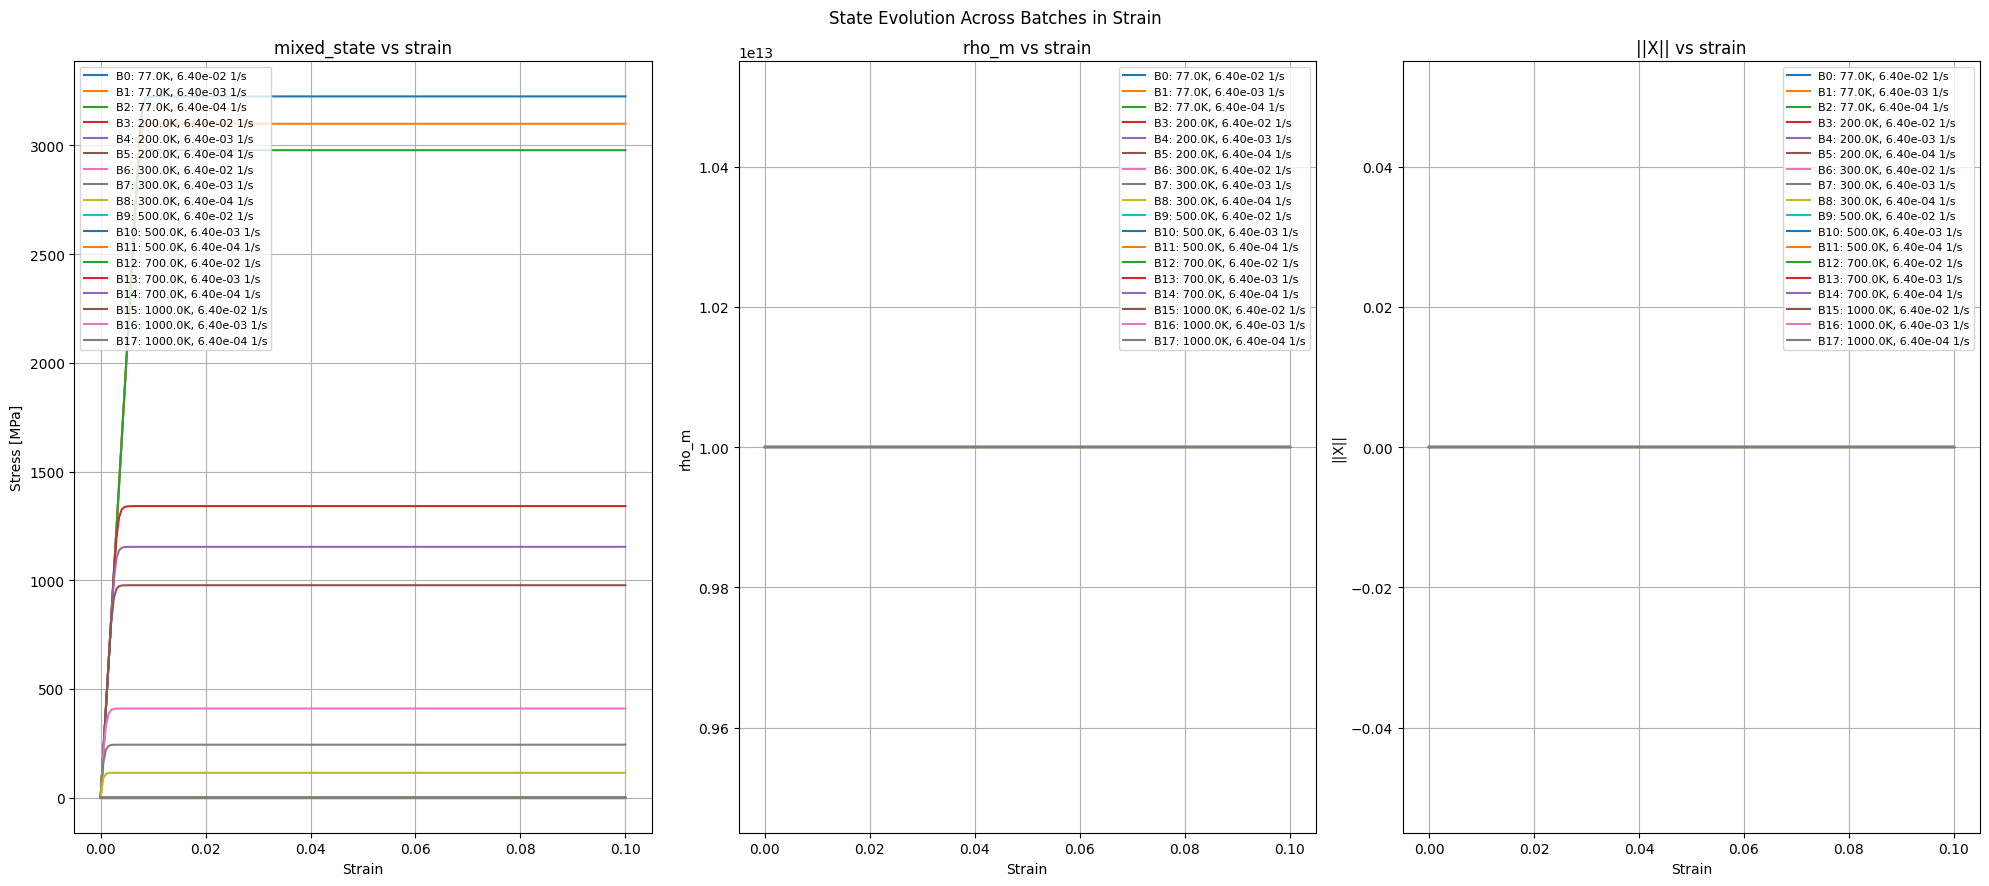

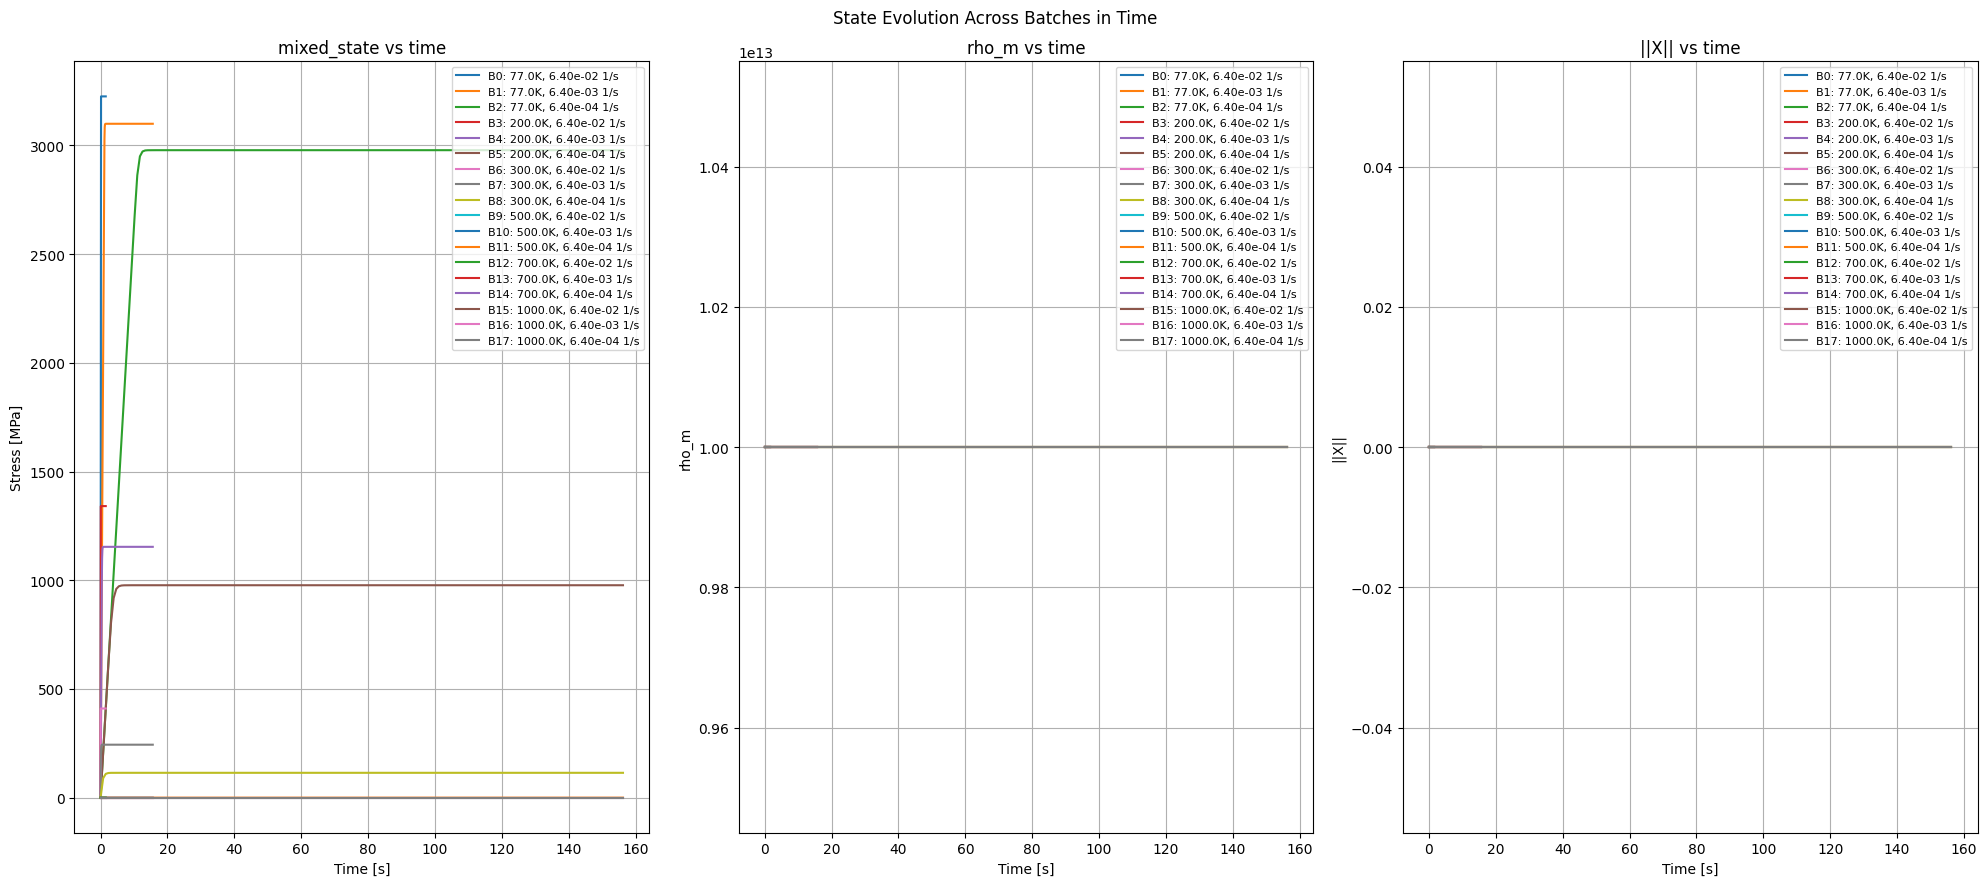

In [8]:
# Debug: inspect internal-variable evolution over time; overlay all batches on two 2x2 figures
with torch.no_grad():
    dbg_solver = nonlinear.RecursiveNonlinearEquationSolver(
        model.discrete_equations,
        step_generator=nonlinear.StepGenerator(model.nchunk),
        predictor=nonlinear.PreviousStepsPredictor(),
        nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=model.rtol, atol=model.atol),
    )

    dbg_control = torch.zeros_like(loading)
    dbg_control[..., 1:] = 1.0

    dbg_forces = model.discrete_equations.forces_asm.assemble_by_variable(
        {
            "forces/t": time,
            "forces/control": dbg_control,
            "forces/T": temperature,
            "forces/fixed_values": loading,
        }
    ).torch()

    dbg_state0 = model.discrete_equations.state_asm.assemble_by_variable(
        {
            "state/internal/rho_m": torch.full(
                dbg_forces.shape[1:-1] + (1,), model.initial_rho_m, device=dbg_forces.device
            )
        }
    ).torch()

    dbg_results = nonlinear.solve_adjoint(dbg_solver, dbg_state0, len(dbg_forces), dbg_forces)

# Convert VariableName keys to strings for safe filtering/sorting/indexing
state_hist_raw = model.discrete_equations.state_asm.split_by_variable(neml2.Tensor(dbg_results, 2))
state_hist = {str(k): v for k, v in state_hist_raw.items()}

forces_hist_raw = model.discrete_equations.forces_asm.split_by_variable(neml2.Tensor(dbg_forces, 1))
forces_hist = {str(k): v.torch() for k, v in forces_hist_raw.items()}

state_names = sorted(state_hist.keys())
print("Available state variables:")
for name in state_names:
    print(" ", name)

forces_names = sorted(forces_hist.keys())
print("Available force variables:")
for name in forces_names:
    print(" ", name)

def get_hist(axis, name):
    return axis[name].torch() if name in state_hist else None

T_in_forces = forces_hist["forces/T"]
E = nmodel.elasticity_E.torch().item()
nu = nmodel.elasticity_nu.torch().item()

alpha = nmodel.athermal_alpha.tensor()
b = nmodel.athermal_b.tensor()
init_rho_m = model.initial_rho_m
L_init = 1 / np.sqrt(init_rho_m)

print(f"\n{'Batch':>5}  {'T_f (expected)':>16}  {'T_f in forces/T':>17}  {'Match':>7}  {'E':>10}  {'nu':>10}  {'G':>10}  {'sigma_a':>10}")
for i, (T_f, rate) in enumerate(conditions):
    T_first = T_in_forces[0,  i, 0].item()
    T_last  = T_in_forces[-1, i, 0].item()
    match = "✓" if abs(T_first - T_f) == 0 and abs(T_last - T_f) == 0 else "✗ MISMATCH"
    G = E / (2.0 * (1.0 + nu))
    sigma_a = (alpha * G * b) / L_init

    print(f"  {i:>3}  {T_f:>16.2f}  {T_first:>17.2f}  {match:>7}  {E:>10.2f}  {nu:>10.3f}  {G:>10.2f}  {sigma_a.item():>10.2f}")

rho_m = get_hist(state_hist, "state/internal/rho_m")
X = get_hist(state_hist, "state/internal/X")

fig_s, ax_s = plt.subplots(1, 3, figsize=(20, 9))
fig_s.suptitle("State Evolution Across Batches in Strain")

fig_t, ax_t = plt.subplots(1, 3, figsize=(20, 9))
fig_t.suptitle("State Evolution Across Batches in Time")

for i, (T, rate) in enumerate(conditions):
    strain_hist = loading[:, i, 0].detach().cpu()
    time_hist = time[:, i, 0].detach().cpu()
    stress11 = stress[:, i, 0].detach().cpu() if stress is not None else None
    rho_m_hist = rho_m[:, i, 0].detach().cpu() if rho_m is not None else None
    x_norm_hist = torch.linalg.norm(X[:, i, :], dim=-1).detach().cpu() if X is not None else None

    rate_i = rate.item()
    label = f"B{i}: {T:.1f}K, {rate_i:.2e} 1/s"

    print(f"\nBatch {i}: T={T:.1f}K, rate={rate_i:.2e} 1/s")
    if rho_m_hist is not None:
        print(f"rho_m: start={rho_m_hist[0].item():.6e}, end={rho_m_hist[-1].item():.6e}")
    if x_norm_hist is not None:
        print(f"||X||: start={x_norm_hist[0].item():.6e}, end={x_norm_hist[-1].item():.6e}")

    if stress11 is not None:
        ax_s[0].plot(strain_hist.numpy(), stress11.numpy(), label=label)
        ax_t[0].plot(time_hist.numpy(), stress11.numpy(), label=label)
    if rho_m_hist is not None:
        ax_s[1].plot(strain_hist.numpy(), rho_m_hist.numpy(), label=label)
        ax_t[1].plot(time_hist.numpy(), rho_m_hist.numpy(), label=label)
    if x_norm_hist is not None:
        ax_s[2].plot(strain_hist.numpy(), x_norm_hist.numpy(), label=label)
        ax_t[2].plot(time_hist.numpy(), x_norm_hist.numpy(), label=label)

ax_s[0].set_title("mixed_state vs strain")
ax_s[0].set_xlabel("Strain")
ax_s[0].set_ylabel("Stress [MPa]")
ax_s[0].grid(True)
ax_s[0].legend(fontsize=8)

ax_s[1].set_title("rho_m vs strain")
ax_s[1].set_xlabel("Strain")
ax_s[1].set_ylabel("rho_m")
ax_s[1].grid(True)
ax_s[1].legend(fontsize=8)

ax_s[2].set_title("||X|| vs strain")
ax_s[2].set_xlabel("Strain")
ax_s[2].set_ylabel("||X||")
ax_s[2].grid(True)
ax_s[2].legend(fontsize=8)

ax_t[0].set_title("mixed_state vs time")
ax_t[0].set_xlabel("Time [s]")
ax_t[0].set_ylabel("Stress [MPa]")
ax_t[0].grid(True)
ax_t[0].legend(fontsize=8)

ax_t[1].set_title("rho_m vs time")
ax_t[1].set_xlabel("Time [s]")
ax_t[1].set_ylabel("rho_m")
ax_t[1].grid(True)
ax_t[1].legend(fontsize=8)

ax_t[2].set_title("||X|| vs time")
ax_t[2].set_xlabel("Time [s]")
ax_t[2].set_ylabel("||X||")
ax_t[2].grid(True)
ax_t[2].legend(fontsize=8)

fig_s.tight_layout()
fig_t.tight_layout()
plt.show()


# Capturing and calculating internal kink-pair nucleation velocity
In order to capture the dislocation velocity, the specific block has to be called and loaded since it does not exist in the state history for the implicit rate. Once it is called, the dislocation velocity was tested for a range of $\tau_{\mathrm{eff}}$ values at the 6 temperatures. For this case, there is no isotropic hardening due to Taylor hardening so $\tau_a$ is zero. The other input is $\rho_m$ which is $10$ $[\mu \mathrm{m}^2]$. 

In [11]:
# Ensure that v_disl inputs are either NEML2 tensors or torch tensors
temps_1D = temperatures.reshape(-1)
tau_eff_1D = torch.linspace(0, 3200, 3200, device=device)
T_grid, tau_grid = torch.meshgrid(temps_1D, tau_eff_1D, indexing='ij')

T_neml2 = T_grid.unsqueeze(-1)
tau_neml2 = tau_grid.unsqueeze(-1)
tau_a_neml2 = torch.zeros_like(tau_neml2)
rho_m_neml2 = torch.full_like(tau_neml2, model.initial_rho_m)

v_disl_model = neml2.load_model("model_validation.i", "v_disl_diag")
v_disl_out = v_disl_model.value({
                                "state/internal/tau_eff"   : tau_neml2,
                                "state/internal/s_a"       : tau_a_neml2,
                                "state/internal/rho_m"     : rho_m_neml2,
                                "forces/T"                 : T_neml2
})

v_disl = v_disl_out["state/internal/v_disl"].torch().squeeze(-1)
tau_ratio = v_disl_out["state/internal/tau_ratio"].torch().squeeze(-1)
delta_G = v_disl_out["state/internal/D_G"].torch().squeeze(-1)
mcl_delta_G = v_disl_out["state/internal/mclD_G"].torch().squeeze(-1)
exp_arg = v_disl_out["state/internal/exp_arg"].torch().squeeze(-1)
print(4*'-'+' Debugging Outputs '+4*'-')
print(f"\n{'Stress Ratio':>15}  {'D_G':>15}  {'Clamped D_G':>15}  {'exp_core':>15}  {'dislocation velocity':>25}")
for i in range(tau_ratio.shape[0]):
    for j in range(tau_ratio.shape[1]):
        print(f"{tau_ratio[i,j].item():>15.4e}  {delta_G[i,j].item():>15.4e}  {mcl_delta_G[i,j].item():>15.4e}  {exp_arg[i,j].item():>15.4e}  {v_disl[i,j].item():>25.4e}")


---- Debugging Outputs ----

   Stress Ratio              D_G      Clamped D_G         exp_core       dislocation velocity
     1.0000e-30       9.7395e-01       9.7395e-01      -1.1963e+02                 0.0000e+00
     4.9276e-04       9.7153e-01       9.7153e-01      -1.1934e+02                 4.0189e-49
     9.8553e-04       9.6957e-01       9.6957e-01      -1.1909e+02                 1.0236e-48
     1.4783e-03       9.6774e-01       9.6774e-01      -1.1887e+02                 1.9219e-48
     1.9711e-03       9.6600e-01       9.6600e-01      -1.1866e+02                 3.1736e-48
     2.4638e-03       9.6432e-01       9.6432e-01      -1.1845e+02                 4.8759e-48
     2.9566e-03       9.6269e-01       9.6269e-01      -1.1825e+02                 7.1496e-48
     3.4494e-03       9.6109e-01       9.6109e-01      -1.1805e+02                 1.0144e-47
     3.9421e-03       9.5953e-01       9.5953e-01      -1.1786e+02                 1.4041e-47
     4.4349e-03       9.5800e-0

# Calculating Analytical Expression for Same Input Parameters

In [13]:
# 1. Explicitly define validation constants (bypassing NEML2 extraction risks)
a = 3.16e-10
b = 2.737e-10
h = 2.581e-10
k_B = 8.617e-5
rho_m_init = model.initial_rho_m # Assuming this is safely defined in your notebook
L_val = 1.0 / (rho_m_init ** 0.5)

Bk = 8.3e-11
H_0 = 1.63
T_0 = 2956.0
p = 0.86
q = 1.69
tau_p = 2030.0

# 2. Calculate prefactor
K = (h * L_val * b) / ((a ** 2) * Bk)

# 3. PyTorch Analytical Calculation
tau_eff_analytical = torch.maximum(tau_eff_1D.reshape(-1), torch.zeros_like(tau_eff_1D.reshape(-1)))
tau_1 = torch.maximum(tau_eff_analytical - 0.0, torch.zeros_like(tau_eff_1D.reshape(-1)))
tau_tilda = tau_1 / tau_p

tau_ratio = torch.clamp(tau_tilda, torch.full_like(tau_tilda, fill_value=1.0e-30), torch.full_like(tau_tilda, fill_value=1.0-1.0e-6))
delta_G = torch.pow(1.0 - torch.pow(tau_ratio, p), q) - T_grid / T_0
delta_G_safe = torch.maximum(delta_G, torch.zeros_like(delta_G))

exp_core = -H_0 * delta_G_safe / (2.0 * k_B * T_grid)
exp_val = torch.exp(exp_core)
v_kp = K * tau_eff_analytical * exp_val
print(v_kp)


tensor([[0.0000e+00, 4.0189e-49, 1.0236e-48,  ..., 8.6196e+06, 8.6223e+06,
         8.6250e+06],
        [0.0000e+00, 2.1482e-16, 4.7156e-16,  ..., 8.6196e+06, 8.6223e+06,
         8.6250e+06],
        [0.0000e+00, 1.4504e-09, 3.0865e-09,  ..., 8.6196e+06, 8.6223e+06,
         8.6250e+06],
        [0.0000e+00, 4.2172e-04, 8.7543e-04,  ..., 8.6196e+06, 8.6223e+06,
         8.6250e+06],
        [0.0000e+00, 9.2584e-02, 1.9016e-01,  ..., 8.6196e+06, 8.6223e+06,
         8.6250e+06],
        [0.0000e+00, 5.2804e+00, 1.0759e+01,  ..., 8.6196e+06, 8.6223e+06,
         8.6250e+06]], device='cuda:0')


# Plotting difference between NEML2 output and Analytical Expression

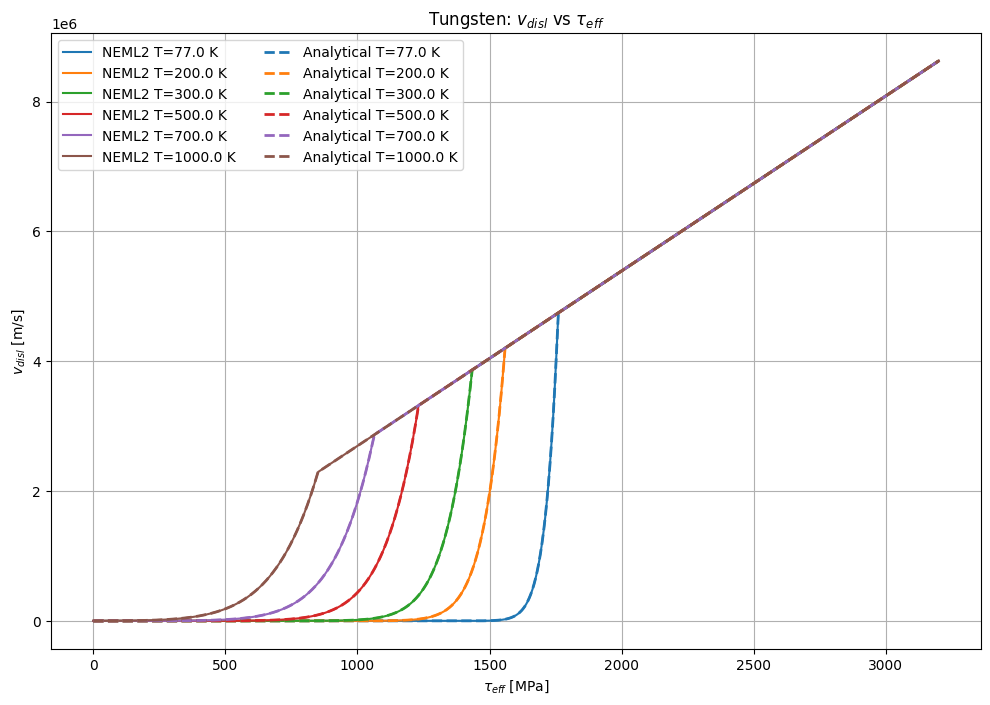

In [14]:
plt.figure(figsize=(12,8))
for i, T in enumerate(temperatures):
    plt.plot(tau_eff_1D.cpu().numpy(), v_disl[i].cpu().numpy(), color=f"C{i}", label=f"NEML2 T={T.item()} K")
for i, T in enumerate(temperatures):
    plt.plot(tau_eff_1D.cpu().numpy(), v_kp[i].cpu().numpy(), "--", color=f"C{i}", lw=2, label=f"Analytical T={T.item()} K")
plt.xlabel(r"$\tau_{eff}$ [MPa]")
plt.ylabel(r"$v_{disl}$ [m/s]")
plt.title(r"Tungsten: $v_{disl}$ vs $\tau_{eff}$")
plt.grid()
plt.legend(ncol=2)
plt.show()

# Running Dislocation Velocity Model for $\tau_{\mathrm{eff}}$ calculated from flow stresses
The same dislocaiton velocity model is called and the effective shear stress is now, instead of being a range of values, a set of $n_{\mathrm{batch}}$ points calculated from the flow stresses as $\tau_{\mathrm{eff}}=m\cdot\sigma$. All other input conditions are the same as the previous dislocation velocity model call.

In [15]:
# Extract flow stresses for each condition
flow_stress = stress[-1, :, 0]
temps = conditions[:, 0]
rates = conditions[:, 1]

# Convert flow stress to shear stress
m = nmodel.shear_eff_m.torch().item()
tau_eff_batch = (m * flow_stress).unsqueeze(-1)
T_batch = temps.unsqueeze(-1)
s_a_batch = torch.zeros_like(tau_eff_batch)
rho_m_batch = torch.full_like(tau_eff_batch, model.initial_rho_m)

v_disl_new_out = v_disl_model.value({
                                "state/internal/tau_eff" : tau_eff_batch,
                                "state/internal/s_a"     : s_a_batch,
                                "state/internal/rho_m"   : rho_m_batch,
                                "forces/T"               : T_batch
})
v_disl_new = v_disl_new_out["state/internal/v_disl"].torch()
v_disl_targets = torch.unique(torch.round(v_disl_new, decimals=8))
print(v_disl_targets)


tensor([2.9000e-07, 2.8600e-06, 2.8640e-05], device='cuda:0')


# Calculating $\tau_{\mathrm{eff}}$ as $g(\mathrm{T}, \boldsymbol{p}, \dot{\gamma})$
The newly calculated $v_{\mathrm{disl}}$ gives 3 unique outputs: $$v_{\mathrm{disl}} = [0.2864, 2.8639, 28.6385] \quad [\mu \mathrm{m}/\mathrm{s}]$$
From these results, the plastic flow rate is calculated as: $$\dot{\gamma}=\rho_m\cdot b\cdot v_{\mathrm{disl}}$$
where $\rho_m=1.0$ $[\mu \mathrm{m}^2]$ instead of the model input of $10.0$ $[\mu \mathrm{m}^2]$. Once $\dot{\gamma}$ is calculated, Brent Method root-finding solvers are used to invert the nonlinear $v_{\mathrm{disl}}$ function. The same process was done for the analytical calculation and the results are compared in the plot generated from the code block below.

    Rates do not match: NEML2: [2.64312090e-05 2.60666406e-04 2.61030974e-03], applied: [0.00064 0.0064  0.064  ]
NEML2 gamma_dot: [7.937300e-05 7.827820e-04 7.838768e-03] | Analytical gamma_dot: [6.00000000e-06 4.80000000e-05 5.80000000e-05 4.08000000e-04
 5.62000000e-04 6.18000000e-04 2.89900000e-03 3.51100000e-03
 1.72220000e-02 5.51202600e+01 5.51511320e+01 5.53744000e+01
 1.71627970e+04 1.71628628e+04 1.71633396e+04 1.41214850e+06
 1.41214862e+06 1.41214946e+06]


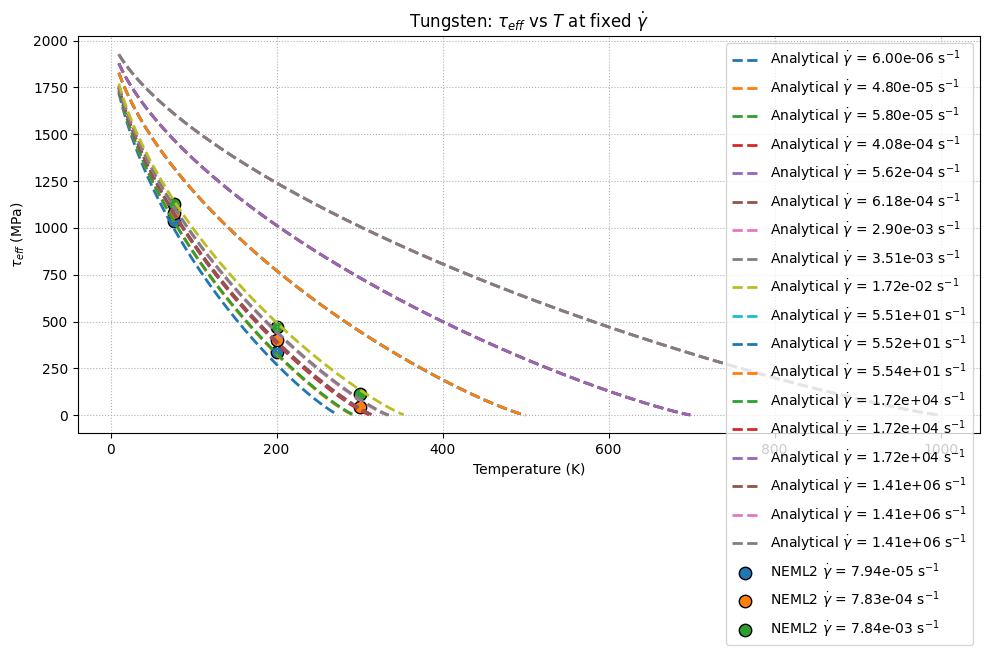

In [19]:
rho_m_init = 1.0e12

# NEML2 gamma_dot
v_disl_np = v_disl_targets.detach().cpu().numpy().flatten()
gamma_dot = b * rho_m_init * v_disl_np

# Converting back to strain rate by multiplying by schmid factor
eps_rate = m * gamma_dot
applied_eps_rate = np.unique(rates.cpu().numpy())

if np.all(abs(eps_rate - applied_eps_rate) < 1e-6):
    print(f"    Applied strain rates match: NEML2 eps_rate: {eps_rate}, applied: {conditions[:,1]}")
else:
    print(f"    Rates do not match: NEML2: {eps_rate}, applied: {applied_eps_rate}")

def v_disl_scalar(tau_eff_val, T_val):
    """Returns scalar v_disl (mm/s) for a single tau_eff, T pair."""
    tau_1          = np.maximum(tau_eff_val - 0.0, 0.0)
    tau_ratio      = tau_1 / tau_p
    tau_ratio_safe = np.clip(tau_ratio, 1e-30, 1.0-1.0e-6)
    delta_G        = (1.0 - tau_ratio_safe**p)**q - T_val/T_0
    delta_G_safe   = np.maximum(delta_G, 0.0)
    exp_core       = -H_0 * delta_G_safe / (2.0 * k_B * T_val)
    exp_val        = np.exp(exp_core)
    L              = 1.0 / (np.sqrt(model.initial_rho_m))
    K              = h * L * b / (a**2 * Bk)
    v_kp           = K * T_val * exp_val

    return v_kp

def gamma_dot_scalar(tau_eff_val, T_val):
    """gamma_dot = rho_L * b * v_disl."""
    return rho_m_init * b * v_disl_scalar(tau_eff_val, T_val)

def invert_tau_eff(gamma_dot_target, T_val, tau_lo=1e-3, tau_hi=None):
    """
    Find tau_eff such that gamma_dot(tau_eff, T_val) == gamma_dot_target.
    Returns NaN if no solution exists in the bracket.
    """
    if tau_hi is None:
        tau_hi = tau_p - 1e-3          # just inside the Peierls stress

    f_lo = gamma_dot_scalar(tau_lo, T_val) - gamma_dot_target
    f_hi = gamma_dot_scalar(tau_hi, T_val) - gamma_dot_target

    if f_lo * f_hi > 0:               # root not bracketed → no solution
        return np.nan

    return brentq(
        lambda tau: gamma_dot_scalar(tau, T_val) - gamma_dot_target,
        tau_lo, tau_hi,
        xtol=1e-6, rtol=1e-8, maxiter=200
    )

T_sweep = np.linspace(10, 1000, 500)           # K

fig, ax = plt.subplots(figsize=(10, 6))

gamma_targets = gamma_dot_scalar(tau_eff_batch.cpu().numpy(), T_batch.cpu().numpy())
gamma_targets = np.unique(np.round(gamma_targets, 6), axis=0).flatten()

print(f"NEML2 gamma_dot: {gamma_dot} | Analytical gamma_dot: {gamma_targets}")

T_points = np.unique(T_batch.cpu().numpy().flatten())

# Analytical curve plotting
for i, gd in enumerate(gamma_targets):
    tau_curve = np.array([invert_tau_eff(gd, T) for T in T_sweep])
    line_color = f"C{i}"
    ax.plot(T_sweep, tau_curve, '--', color=line_color, lw=2, label=rf"Analytical $\dot{{\gamma}}$ = {gd:.2e} s$^{{-1}}$")

for i, gd in enumerate(gamma_dot):
    tau_points = np.array([invert_tau_eff(gd, T) for T in T_points])
    line_color = f"C{i}"
    ax.scatter(T_points, tau_points, s=80,color=line_color, edgecolors="black", label=rf"NEML2 $\dot{{\gamma}}$ = {gd:.2e} s$^{{-1}}$")


ax.set_xlabel("Temperature (K)")
ax.set_ylabel(r"$\tau_{eff}$ (MPa)")
ax.set_title(r"Tungsten: $\tau_{eff}$ vs $T$ at fixed $\dot{\gamma}$")
ax.legend()
ax.grid(ls=":")
plt.tight_layout()
plt.show()
